![QuantConnect Logo](https://cdn.quantconnect.com/web/i/icon.png)
<hr>

## Quiver CNBC Trading Research

This notebook studies whether CNBC buy-recommendation count helps explain future returns

In [1]:
qb = QuantBook()
# Daily bars will have an end_time that matches the following midnight.
qb.settings.daily_precise_end_time = False

### Build a CNBC Universe

Select assets with 3 or more BUY recommendations from CNBC commentators, then inspect the returned universe history.

In [2]:
def select_assets(data: List[QuiverCNBCsUniverse]) -> List[Symbol]:
    # Group raw CNBC opinions by ticker so we can score each name.
    cnbc_by_symbol: dict[Symbol, list[QuiverCNBCsUniverse]] = {}
    for d in data:
        cnbc_by_symbol.setdefault(d.symbol, []).append(d)
    # Keep names with 3+ BUY recommendations to filter out noise.
    return [s for s, ds in cnbc_by_symbol.items()
            if sum(1 for d in ds if d.direction == OrderDirection.BUY) >= 3]

# Add the Quiver CNBC universe.
universe = qb.add_universe(QuiverCNBCsUniverse, select_assets)
# Request universe history of the last 365 days.
universe_history = qb.universe_history(universe, qb.time - timedelta(365), qb.time - timedelta(1), flatten=True)
# Print the returned shape and columns.
print(f"Shape: {universe_history.shape}")
print(f"Columns: {list(universe_history.columns)}")
universe_history.head()

Shape: (439, 4)
Columns: ['advicedate', 'direction', 'time', 'traders']


advicedate direction       time       traders
time                                                                     
2025-06-02 DIS R735QTJ8XC9X 2025-06-01       Buy 2025-06-02     Guy Adami
           DIS R735QTJ8XC9X 2025-06-01       Buy 2025-06-02    Julie Biel
           DIS R735QTJ8XC9X 2025-06-01       Buy 2025-06-02   Tim Seymour
           DIS R735QTJ8XC9X 2025-06-01      Hold 2025-06-02  Carter Worth
2025-06-03 BA R735QTJ8XC9X  2025-06-02       Buy 2025-06-03     Guy Adami

### Universe Diagnostics

Inspects the raw CNBC direction distribution and visualizes how the unique asset footprint expands chronologically.

Universe days: 128
Mean basket size per day: 1.5

count     439
unique      3
top       Buy
freq      401
Name: direction, dtype: object


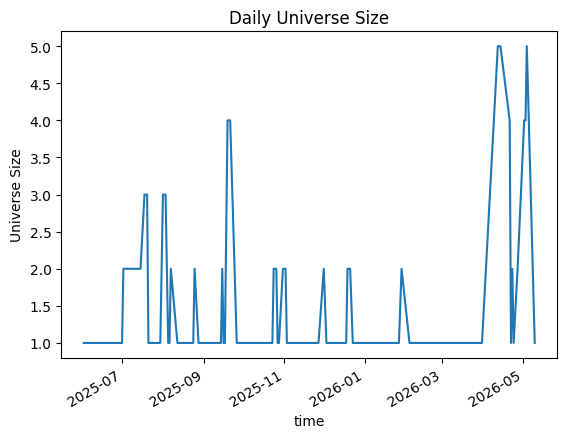

In [3]:
# Count selected assets by day.
universe_size = universe_history[universe_history.direction == OrderDirection.BUY].groupby(level=[0, 1]).count().direction.groupby(level=0).count()
print(f"Universe days: {len(universe_size)}")
# Store the selected symbol list.
unique_assets = list(universe_history.index.levels[1].unique())
print(f"Mean basket size per day: {universe_size.mean():.1f}")
print('')
print(universe_history.direction.describe())
universe_size.plot(title='Daily Universe Size', ylabel='Universe Size');

### Daily Universe Prices

Fetch daily price history for every symbol that appears in the universe.

In [4]:
# Extract unique assets
symbols = list(universe_history.index.get_level_values(1).unique())
# Fetch daily historical price metrics using the earliest timestamp available in the index.
history = qb.history(symbols, universe_history.index[0][0] - timedelta(1), qb.time, Resolution.DAILY)
history

close        high         low        open  \
symbol           time                                                         
DIS R735QTJ8XC9X 2025-06-03  111.714530  112.347530  111.022187  111.506827   
                 2025-06-04  112.357420  113.435498  111.309015  111.491991   
                 2025-06-05  112.248624  112.792608  111.773874  112.673920   
                 2025-06-06  111.299124  113.089326  110.626562  112.367311   
                 2025-06-07  112.644248  112.970639  112.120046  112.624467   
...                                 ...         ...         ...         ...   
XON R735QTJ8XC9X 2026-05-23  154.920000  155.530000  153.170000  154.030000   
                 2026-05-27  149.810000  154.550000  149.480000  153.500000   
                 2026-05-28  147.900000  148.685000  145.840000  147.225000   
                 2026-05-29  147.000000  150.180000  146.870000  149.340000   
                 2026-05-30  145.330000  146.920000  144.710000  146.100000   

                                 volume  
symbol           time                    
DIS R735QTJ8XC9X 2025-06-03   6704791.0  
                 2025-06-04   8239115.0  
                 2025-06-05   5543754.0  
                 2025-06-06   8325729.0  
                 2025-06-07   4854050.0  
...                                 ...  
XON R735QTJ8XC9X 2026-05-23  12112414.0  
                 2026-05-27  12121531.0  
                 2026-05-28  13696288.0  
                 2026-05-29   9846087.0  
                 2026-05-30  10475825.0  

[11250 rows x 5 columns]

### Align CNBC Signals And Returns

Build a joined table of buy counts and future returns.

In [ ]:
dataset = (
    universe_history.groupby(level=[0, 1]).agg(buycount=('direction', lambda x: (x == OrderDirection.BUY).sum())).rename_axis(['time', 'symbol'])
    .join(history.open.unstack('symbol').sort_index().pct_change(2).shift(-2).stack().rename('futurereturn').rename_axis(['time','symbol']), how='inner')
)
dataset.head()

,,buycount,futurereturn
time,symbol,,
2025-06-03,BA R735QTJ8XC9X,3,0.013020
2025-06-05,AVGO UEW4IOBWVPT1,3,-0.026250
2025-06-11,ORCL R735QTJ8XC9X,4,0.069158
2025-07-01,AAPL R735QTJ8XC9X,3,0.035371
2025-07-02,AAPL R735QTJ8XC9X,1,0.025880


### Analyze Relationships Between Factor and Future Returns

Create a box plot of buy-count quantile buckets compared to future returns.

Factor: buycount


,bucket,mean_factor,min_future_return,max_future_return,mean_future_return,std_future_return,observations
0,"(0.999, 3.0]",1.930,-10.51%,14.57%,1.37%,4.12%,114
1,"(3.0, 6.0]",4.538,-2.95%,12.38%,3.23%,5.33%,13


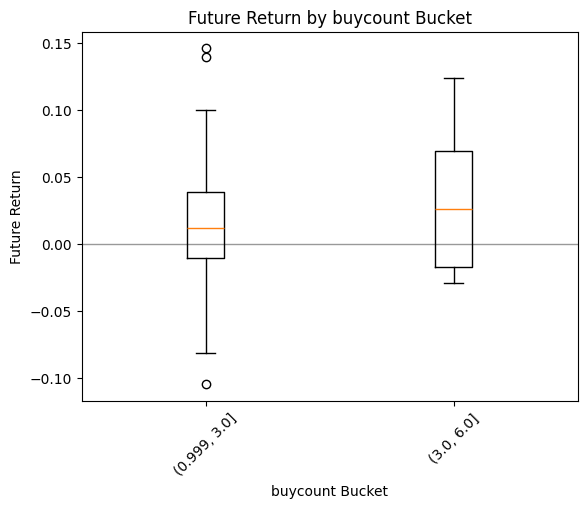

In [ ]:
factor = 'buycount'
# Split factor values into quantile buckets.
x = dataset[factor]
y = dataset['futurereturn']
buckets = pd.qcut(x, q=x.nunique(), duplicates='drop')
# Summarize each bucket with distribution statistics.
summary = dataset.assign(bucket=buckets).groupby('bucket', observed=True).agg(
    mean_factor=(factor, 'mean'),
    min_future_return=('futurereturn', 'min'),
    max_future_return=('futurereturn', 'max'),
    mean_future_return=('futurereturn', 'mean'),
    std_future_return=('futurereturn', 'std'),
    observations=('futurereturn', 'size')
).reset_index()
summary['bucket'] = summary['bucket'].astype(str)
# Display the bucket summary.
print(f"Factor: {factor}")
display(summary.style.format({
    'mean_factor': '{:.3f}',
    'min_future_return': '{:.2%}',
    'max_future_return': '{:.2%}',
    'mean_future_return': '{:.2%}',
    'std_future_return': '{:.2%}'
}))
# Plot the return distribution for each bucket.
groups = [y[buckets == b].values for b in buckets.cat.categories]
plt.boxplot(groups, labels=[str(b) for b in buckets.cat.categories])
plt.axhline(0, color='black', linewidth=1, alpha=0.4)
plt.title(f'Future Return by {factor} Bucket')
plt.xlabel(f'{factor} Bucket')
plt.ylabel('Future Return')
plt.xticks(rotation=45)
plt.show()